## Sentiment Classification Model

*Models to use:*
- Classifier: distilbert-base-uncased

## Load Data

In [15]:
import pandas as pd
import torch
import pandas as pd

import pandas as pd

df = pd.read_csv(
    "/content/clean_reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

#inspect the dataset
df.head()

,name,reviews.rating,reviews.text,sentiment,clean_review
0,AmazonBasics AAA Performance Alkaline Batterie...,3,I order 3 of them and one of the item is bad q...,neutral,i order 3 of them and one of the item is bad q...
1,AmazonBasics AAA Performance Alkaline Batterie...,4,Bulk is always the less expensive way to go fo...,positive,bulk is always the less expensive way to go fo...
2,AmazonBasics AAA Performance Alkaline Batterie...,5,Well they are not Duracell but for the price i...,positive,well they are not duracell but for the price i...
3,AmazonBasics AAA Performance Alkaline Batterie...,5,Seem to work as well as name brand batteries a...,positive,seem to work as well as name brand batteries a...
4,AmazonBasics AAA Performance Alkaline Batterie...,5,These batteries are very long lasting the pric...,positive,these batteries are very long lasting the pric...


## Data Exploration
- Inspect dataset structure, size, and sentiment distribution.

In [16]:
df.shape
df["sentiment"].value_counts()
#Data is still heavily imbalanced, mostly positive

,count
sentiment,
positive,54893
neutral,2664
negative,2343


## Label Encoding
- Convert sentiment labels (text) into numerical values for the model.

In [17]:
#convert sentiment labels to numbers
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

#apply the mapping to create the column "label"
df["label"] = df["sentiment"].map(label_map)

#show both columns to verify the mapping work
df[["sentiment", "label"]].head()

,sentiment,label
0,neutral,1
1,positive,2
2,positive,2
3,positive,2
4,positive,2


## Train-Test Split
- Split data into training and testing sets.

In [18]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

print("Train size:", len(X_train))
print("test size:", len(X_test))


Train size: 47920
test size: 11980


##Baseline Model: TF-IDF + Logistic Regression

Before applying a transformer-based model, we use a simple baseline approach with TF-IDF and Logistic Regression.  
This helps us understand how much performance improvement we gain from more advanced models.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Initiate TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

#predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

#evaluation
accuracy = accuracy_score(y_test, y_pred_lr)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_lr, average="weighted")

print("TF-IDF Accuracy:", accuracy)
print("TF-IDF Precision:", precision)
print("TF-IDF Recall:", recall)
print("TF-IDF F1:", f1)

TF-IDF Accuracy: 0.9385642737896495
TF-IDF Precision: 0.9286327232231516
TF-IDF Recall: 0.9385642737896495
TF-IDF F1: 0.923605026274807


##Baseline Results

- TF-IDF achieves strong performance (~92% accuracy)
- This shows that simple models can already capture useful patterns in the data
- However, TF-IDF does not understand context or word relationships

## Tokenization
- Convert text into numerical format for the model

In [20]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

sample = X_train.iloc[0]

tokens = tokenizer(
    sample,
    paddding="max_length",
    truncation=True,
    max_length=128
)

tokens

{'input_ids': [101, 5310, 5379, 2130, 2005, 1037, 2512, 6627, 2666, 2711, 2066, 2026, 3566, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [21]:
#Take only 100 reviews from training data
small_train = X_train.head(100).tolist()

#tokenize those 100 reviews
small_encodings = tokenizer(
    small_train,
    padding=True,
    truncation=True,
    max_length=128
)
#show what the tokenizer created
print(small_encodings.keys())

#show how many reviews were processed
print(len(small_encodings["input_ids"]))

KeysView({'input_ids': [[101, 5310, 5379, 2130, 2005, 1037, 2512, 6627, 2666, 2711, 2066, 2026, 3566, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 3733, 2000, 2224, 3113, 4781, 2026, 4268, 2428, 5632, 2009, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2307, 13855, 2005, 1996, 3976, 1045, 2525, 2031, 1017, 8771, 2164, 1996, 10751, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [22]:
#function to tokenize in chunks (is faster and we avoid freezing)
def batch_tokenize(texts, tokenizer, batch_size=1000):
    input_ids = []
    attention_masks = []

    #loop through dataset in batches
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        encodings = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128
        )
        #store results
        input_ids.extend(encodings["input_ids"])
        attention_masks.extend(encodings["attention_mask"])

        print(f"Processed {i + len(batch)} / {len(texts)}")

    return {
        "input_ids": input_ids,
        "attention_mask": attention_masks
    }

#apply to full dataset
train_encodings = batch_tokenize(X_train.tolist(), tokenizer)
test_encodings = batch_tokenize(X_test.tolist(), tokenizer)

Processed 1000 / 47920
Processed 2000 / 47920
Processed 3000 / 47920
Processed 4000 / 47920
Processed 5000 / 47920
Processed 6000 / 47920
Processed 7000 / 47920
Processed 8000 / 47920
Processed 9000 / 47920
Processed 10000 / 47920
Processed 11000 / 47920
Processed 12000 / 47920
Processed 13000 / 47920
Processed 14000 / 47920
Processed 15000 / 47920
Processed 16000 / 47920
Processed 17000 / 47920
Processed 18000 / 47920
Processed 19000 / 47920
Processed 20000 / 47920
Processed 21000 / 47920
Processed 22000 / 47920
Processed 23000 / 47920
Processed 24000 / 47920
Processed 25000 / 47920
Processed 26000 / 47920
Processed 27000 / 47920
Processed 28000 / 47920
Processed 29000 / 47920
Processed 30000 / 47920
Processed 31000 / 47920
Processed 32000 / 47920
Processed 33000 / 47920
Processed 34000 / 47920
Processed 35000 / 47920
Processed 36000 / 47920
Processed 37000 / 47920
Processed 38000 / 47920
Processed 39000 / 47920
Processed 40000 / 47920
Processed 41000 / 47920
Processed 42000 / 47920
P

In [23]:
print(len(train_encodings["input_ids"]))
print(len(train_encodings["attention_mask"]))
print(len(test_encodings["input_ids"]))
print(len(test_encodings["attention_mask"]))

47920
47920
11980
11980


## Create PyTorch Dataset
- Prepare tokenized reviews and labels for model training.

In [24]:
#custom dataset class for our reviews
class ReviewDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        #store tokenized text
        self.encodings = encodings
        #store sentiment labels
        self.labels = labels

    def __getitem__(self, idx):
        #get one review by index and convert to tensors
        item = {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels.iloc[idx])
        }

        return item

    def __len__(self):
        #return num of reviews
        return len(self.labels)

#create the dataset objects for train and test
train_dataset = ReviewDataset(train_encodings, y_train)
test_dataset = ReviewDataset(test_encodings, y_test)

#check dataset sized
len(train_dataset), len(test_dataset)

(47920, 11980)

## Load Classification Model
- Load DistilBERT with 3 output labels: negative, neutral, positive.

In [14]:
from transformers import DistilBertForSequenceClassification

#load DistilBert and prepare for 3-class classification
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training Setup
- Define how the model should train.

In [25]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="../outputs/results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=100
)

## Trainer Setup
- Connect model, data, and training configuration.

In [26]:
from transformers import Trainer

#create trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

## Train Model
- Fine-tune DistilBERT on Amazon review sentiment labels.

In [27]:
trainer.train()

Step,Training Loss
100,0.719861
200,0.363627
300,0.332848
400,0.329146
500,0.327246
600,0.249522
700,0.255059
800,0.272700
900,0.309341
1000,0.241899


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5990, training_loss=0.23071585019960228, metrics={'train_runtime': 799.2685, 'train_samples_per_second': 59.955, 'train_steps_per_second': 7.494, 'total_flos': 1586987737067520.0, 'train_loss': 0.23071585019960228, 'epoch': 1.0})

## Model Evaluation
- Evaluating model performance on test data.

In [28]:
results = trainer.evaluate()

results

{'eval_loss': 0.17882154881954193,
 'eval_runtime': 49.9903,
 'eval_samples_per_second': 239.646,
 'eval_steps_per_second': 29.966,
 'epoch': 1.0}

## Detailed Evaluation Metrics
- Calculating accuracy, precision, recall, and F1-score.

In [29]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

#get model predictions on test data
predictions = trainer.predict(test_dataset)

#convert prediction scores into predicted class labels
y_pred = predictions.predictions.argmax(axis=1)

#true labels
y_true = y_test.values

#calculate metrics
accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

#High accuracy is partly misleading, Model might be biased toward positive
#Dataset is heavily imbalanced with positive reviews

Accuracy: 0.9522537562604341
Precision: 0.9446683010377253
Recall: 0.9522537562604341
F1-score: 0.9460489385916123


## Confusion Matrix
- Analyze where the model makes mistakes.

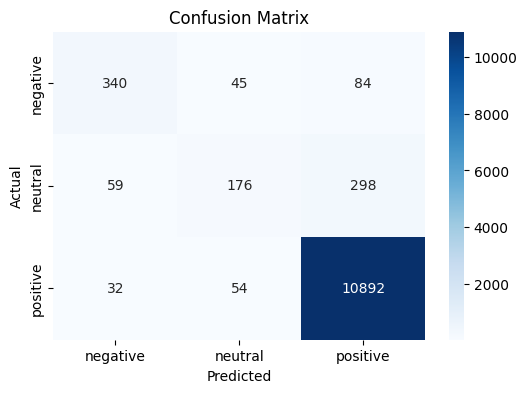

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Key Findings

- Model achieves high accuracy (~95%)
- Strong performance on positive reviews
- Weak performance on neutral reviews

## Limitations

- Dataset is imbalanced (mostly positive reviews)
- This imbalance biases the model towards predicting positive reviews

##Model Comparison

- TF-IDF baseline: ~92% accuracy, fast and simple
- DistilBERT: ~95% accuracy, better contextual understanding
- Transformer models outperform traditional methods on complex text data